# Import Statements

In [23]:
# data structures
import numpy as np
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.colors import Normalize

# Graph representations
import networkx as nx

# dateTime
from datetime import datetime

# Spatial tools
from geopy.distance import geodesic

### Get Flight Dataset

Get path:

In [4]:
path = "/Users/ladylo/PycharmProjects/FlightForensics/data/processed/logs/flight/DF061/path_construction/cleaned_18-06-19-02-04-47_path_log.csv"

Get dataset in DataFrame format:

In [5]:
flight_path = pd.read_csv(path)

Check first five rows:

In [6]:
flight_path.head()

,clock_offset,imu_longitude,imu_latitude,imu_rel_height,roll,pitch,yaw,vel_north,vel_east,vel_down,...,dist_travelled,gps_longitude,gps_latitude,gps_timestamp,gps_heightMSL,gps_vel_north,gps_vel_east,gps_vel_down,control_mode,motor_state
0,-344.350,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.000,-106.216454,39.961194,-2.224854,1.097724,-2.153399,-117.847337,0.001575,0.003628,0.048467,...,227.319476,-106.216454,39.961194,2018-06-19 20:08:27+00:00,2485.657,0.0,0.0,0.02,GPS_Atti,0.0
2,0.039,-106.216454,39.961194,-0.546142,1.119289,-2.155384,-117.846310,0.003867,0.001742,0.043274,...,227.320359,-106.216454,39.961194,2018-06-19 20:08:27+00:00,2485.657,0.0,0.0,0.02,GPS_Atti,0.0
3,0.101,-106.216454,39.961194,-0.546142,1.119289,-2.155384,-117.846310,0.003867,0.001742,0.043274,...,227.320359,-106.216454,39.961194,2018-06-19 20:08:27+00:00,2485.657,0.0,0.0,0.02,GPS_Atti,0.0
4,0.143,-106.216454,39.961194,-0.959717,1.119977,-2.177045,-118.033396,0.004856,-0.002387,0.060550,...,227.325939,-106.216454,39.961194,2018-06-19 20:08:27+00:00,2485.657,0.0,0.0,0.02,ASST_TAKEOFF,1.0


In [7]:
flight_path.shape

(3423, 30)

# Data Preparation

## Drop missing coordinates

In [8]:
flight_path = flight_path.dropna(subset=["imu_calc_lat",
                                         "imu_calc_long",
                                         "gps_latitude",
                                         "gps_longitude",
                                         "gps_timestamp"])

In [9]:
flight_path.shape

(3421, 30)

## Convert gps_timestamp to dateTime format

In [10]:
flight_path["gps_timestamp"] = pd.to_datetime(flight_path["gps_timestamp"])

## Sort Dataframe by Time

In [11]:
flight_path = flight_path.sort_values(by="gps_timestamp").reset_index(drop=True)

# Create graph representation

In [12]:
# Initialize a directed graph
G = nx.DiGraph()

In [13]:
# Create the graph nodes
for i, row in flight_path.iterrows():
  imu_pos = (row["imu_calc_lat"], row["imu_calc_long"])
  gps_pos = (row["gps_latitude"], row["gps_longitude"])

  G.add_node(
      i,                                   # Node identifier
      pos=imu_pos,                         # Drone path coordinates from sensors
      timestamp=row["gps_timestamp"],      # Timestamp of movement
      control_mode=row["control_mode"],    # Drone Mode attribute
      motor_state=row["motor_state"],      # State of motor attribute
      vel=row["vel_composite"],            # Velocity attribute
      dist_travelled=row["dist_travelled"],   # Distance traveled attribute
      gps_pos=gps_pos              # Use GPS coordinates for deviation analysis
  )

In [14]:
# Connect nodes - already in sequential order :)
for i in range(len(flight_path) - 1):   # acyclic, directed graph

  # Calculate delta time - the difference of time traveled node-to-node
  t1 = flight_path.loc[i, "gps_timestamp"]
  t2 = flight_path.loc[i + 1, "gps_timestamp"]
  delta_time = (t2 - t1).total_seconds()

  # Calculate the distance in meters
  pos1 = (flight_path.loc[i]["imu_calc_lat"], flight_path.loc[i]["imu_calc_long"])
  pos2 = (flight_path.loc[i + 1]["imu_calc_lat"], flight_path.loc[i + 1]["imu_calc_long"])
  distance = geodesic(pos1, pos2).meters

  # Calculate the speed
  speed = distance / delta_time if delta_time != 0 else 0

  # Add edge to graph
  G.add_edge(i,                        # current node to
             i+1,                      # next node

             # Add weights (attributes)
             delta_time=delta_time,
             distance=distance,
             speed=speed
            )

# Graph Representations

In [15]:
# create dictionary mapping position for plotting
pos = nx.get_node_attributes(G, "pos")
print(pos)

{0: (39.96119402595874, -106.21645369245395), 1: (39.96119403163552, -106.21645370795754), 2: (39.96119403307834, -106.21645370850176), 3: (39.96119403307834, -106.21645370850176), 4: (39.9611940396603, -106.21645370910603), 5: (39.961194046761165, -106.21645370768336), 6: (39.961194046761165, -106.21645370768336), 7: (39.96119405077408, -106.21645370441016), 8: (39.96119405077408, -106.21645370441016), 9: (39.9611940396603, -106.21645370910603), 10: (39.96119404533968, -106.21645370164325), 11: (39.96119403410045, -106.21645369821545), 12: (39.96119403410045, -106.21645369821545), 13: (39.961194028714935, -106.21645369606894), 14: (39.961194028714935, -106.21645369606894), 15: (39.96119402823389, -106.21645369391288), 16: (39.96119402823389, -106.21645369391288), 17: (39.96119402595874, -106.21645369245395), 18: (39.96119404533968, -106.21645370164325), 19: (39.96119409446899, -106.21645368561616), 20: (39.96119410484724, -106.2164536767723), 21: (39.96119410484724, -106.2164536767723

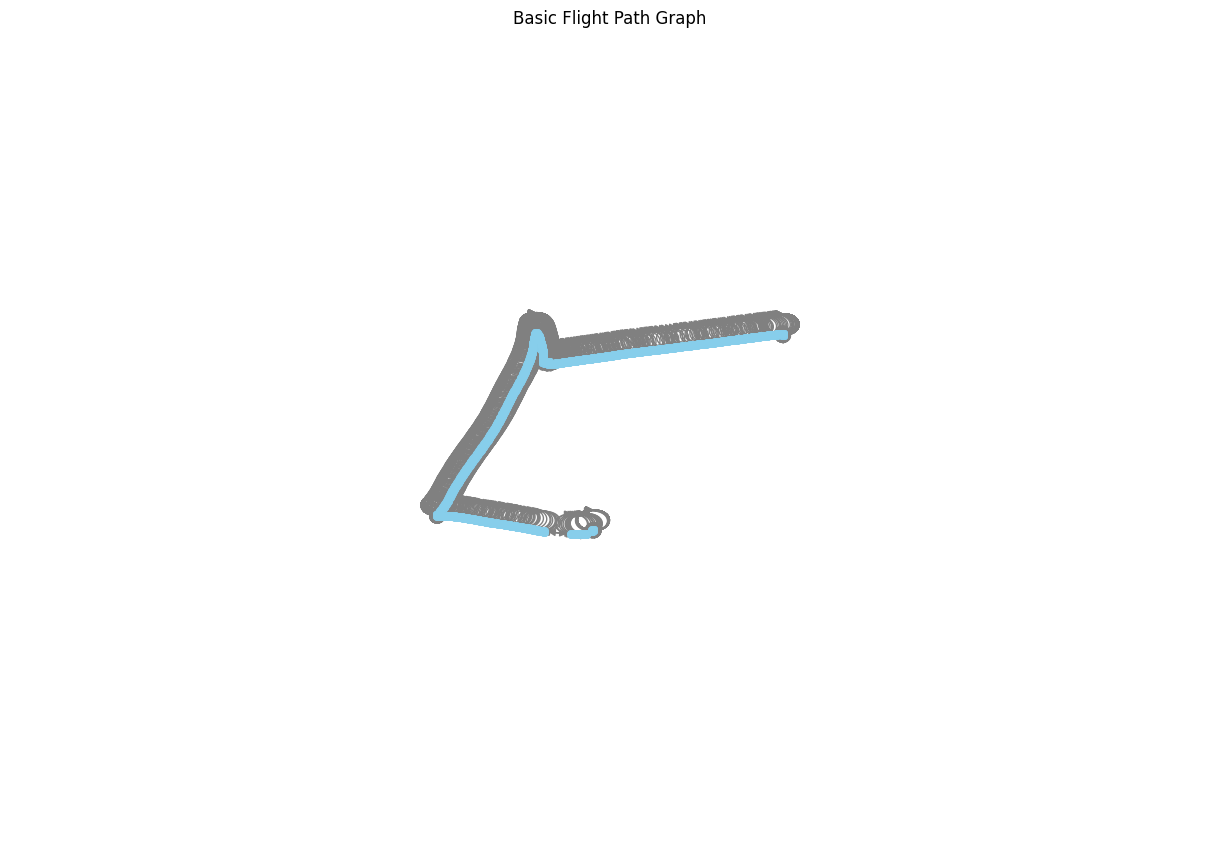

In [16]:
# Create figure of basic graph
plt.figure(figsize=(12, 8))
nx.draw(G,
        pos,
        node_size=30,
        node_color="skyblue",
        edge_color="gray",
        with_labels=False
        )

plt.title("Basic Flight Path Graph")
plt.show()

In [17]:
# Form dictionary mapping GPS attributes
gps_pos = nx.get_node_attributes(G, "gps_pos")
print(gps_pos)

{0: (39.961194, -106.2164536), 1: (39.961194, -106.2164536), 2: (39.961194, -106.2164536), 3: (39.961194, -106.2164536), 4: (39.961194, -106.2164536), 5: (39.961194, -106.2164536), 6: (39.961194, -106.2164536), 7: (39.961194, -106.2164536), 8: (39.961194, -106.2164536), 9: (39.961194, -106.2164536), 10: (39.961194, -106.2164536), 11: (39.961194, -106.2164536), 12: (39.961194, -106.2164536), 13: (39.961194, -106.2164536), 14: (39.961194, -106.2164536), 15: (39.961194, -106.2164536), 16: (39.961194, -106.2164536), 17: (39.961194, -106.2164536), 18: (39.961194, -106.2164536), 19: (39.9611939, -106.2164535), 20: (39.9611939, -106.2164535), 21: (39.9611939, -106.2164535), 22: (39.9611939, -106.2164535), 23: (39.9611939, -106.2164535), 24: (39.9611939, -106.2164535), 25: (39.9611939, -106.2164535), 26: (39.9611939, -106.2164535), 27: (39.9611939, -106.2164535), 28: (39.9611939, -106.2164535), 29: (39.961194, -106.2164535), 30: (39.9611939, -106.2164535), 31: (39.9611939, -106.2164535), 32: (

(None,)

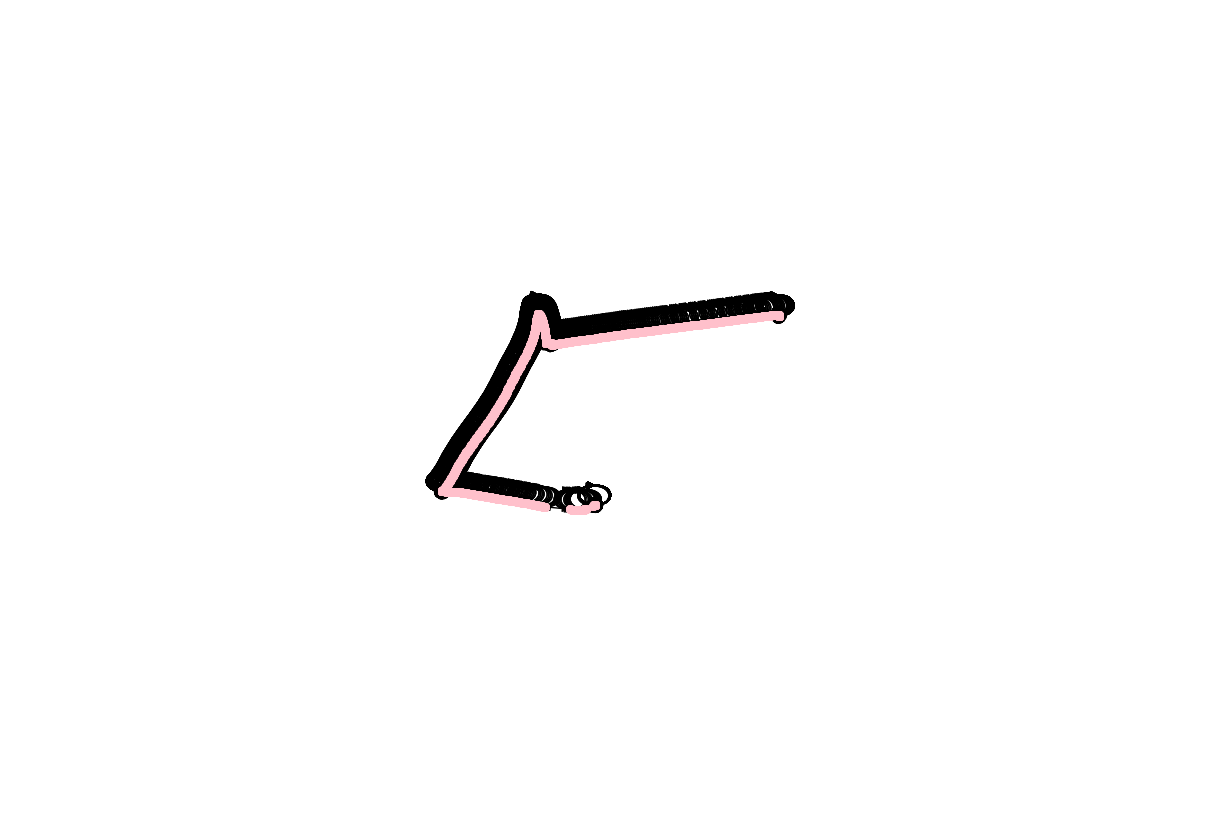

In [18]:
# Create graph of GPS coordinates
plt.figure(figsize=(12, 8))

nx.draw(G,
        gps_pos,
        node_size=30,
        node_color="pink"),


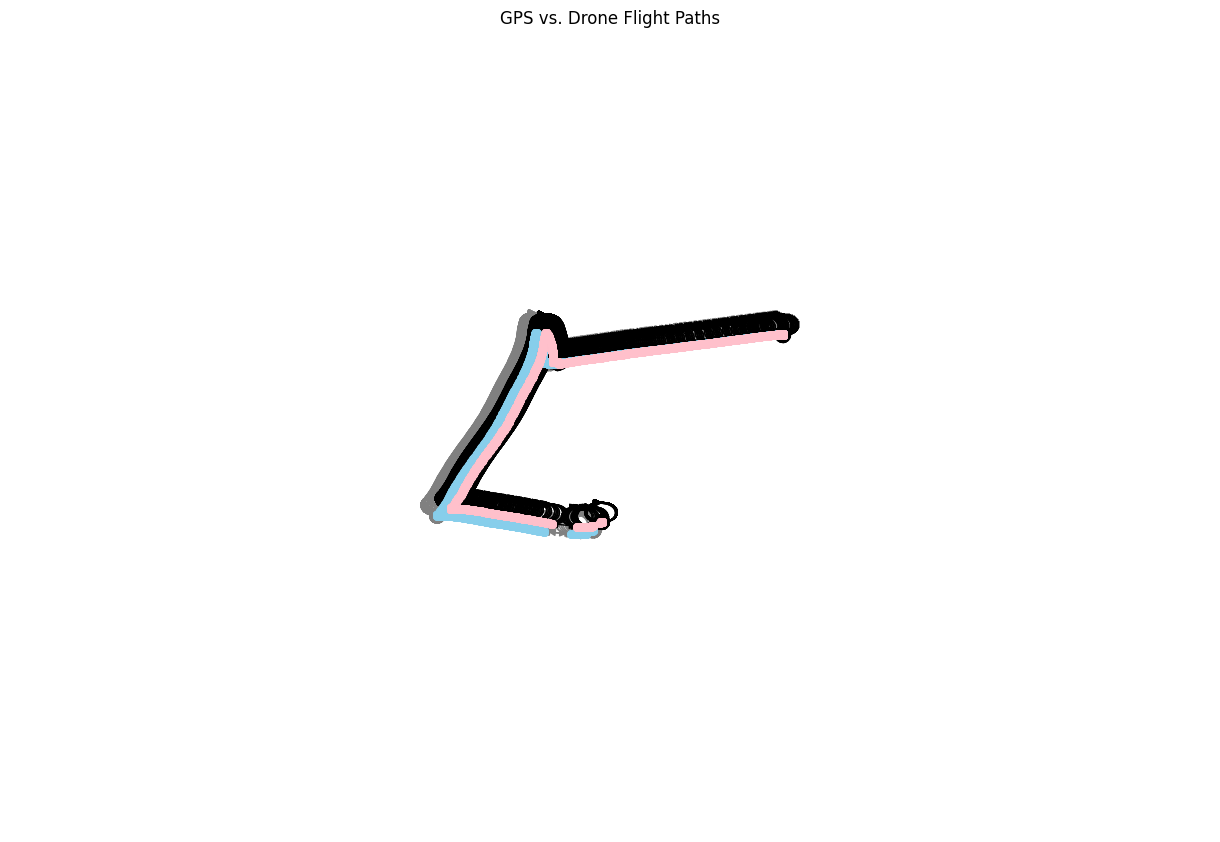

In [19]:
# Combine both plots to compare
plt.figure(figsize=(12, 8))

nx.draw(G,
        pos,
        node_size=30,
        node_color="skyblue",
        edge_color="gray",
        with_labels=False
        )

nx.draw(G,
        gps_pos,
        node_size=30,
        node_color="pink",
        edge_color="black",
        with_labels=False
        )

plt.title("GPS vs. Drone Flight Paths")
plt.show()